# Activation Functions in Neural Networks

Activation functions decide whether a neuron should "fire" or not.
Without them, a neural network is just a linear model — no matter how many layers you add.

We compare two types:
- **Linear** — no non-linearity, can't learn complex patterns
- **Non-linear (ReLU)** — enables the network to learn curves and boundaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Dataset

We use the **Moons dataset** — two interleaving half-circles that are not linearly separable.
This makes it a good test for whether an activation function can handle non-linear boundaries.

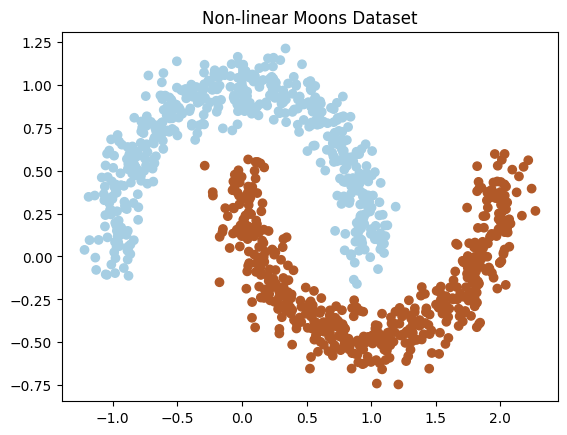

In [ ]:
# Generate a non-linear dataset (e.g., Moons dataset)
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.title("Non-linear Moons Dataset")
plt.show()

## 1. Linear Activation

- Formula: `f(x) = x`
- Output is just the input — no transformation
- Stacking linear layers = still one linear layer
- **Problem:** can't separate non-linear data (e.g. moons dataset)

In [ ]:
# Define a neural network with linear activation functions
model_linear = Sequential([
    Dense(16, activation='linear', input_shape=(2,)),  # First hidden layer
    Dense(16, activation='linear'),                   # Second hidden layer
    Dense(1, activation='sigmoid')                    # Output layer for binary classification
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the linear model
model_linear.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the linear model
history_linear = model_linear.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)


In [ ]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy with Linear Activation: 0.89
4163/4163 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


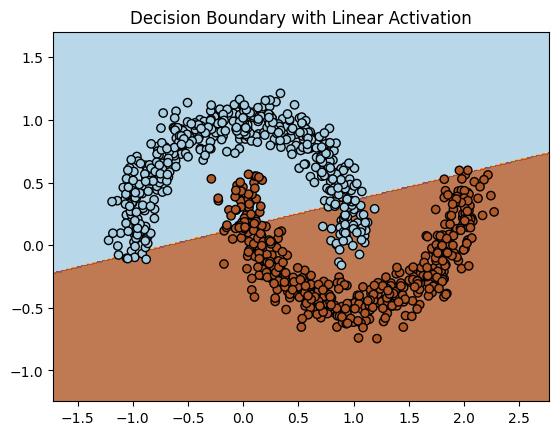

In [ ]:
# Evaluate the linear model
y_pred_linear = (model_linear.predict(X_test) > 0.5).astype(int)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print("Accuracy with Linear Activation:", accuracy_linear)

# Plot decision boundary for linear activation model
plot_decision_boundary(model_linear, X, y, "Decision Boundary with Linear Activation")

## 2. Non-Linear Activation — ReLU

- Formula: `f(x) = max(0, x)`
- Outputs 0 for negative inputs, passes positive inputs as-is
- Introduces non-linearity → network can learn complex boundaries
- **Result:** much better accuracy on non-linear data

In [ ]:
# Define a neural network with non-linear activation functions (ReLU)
model_nonlinear = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),  # First hidden layer
    Dense(16, activation='relu'),                   # Second hidden layer
    Dense(1, activation='sigmoid')                  # Output layer for binary classification
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile and train the non-linear model
model_nonlinear.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nonlinear.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy with Non-Linear Activation: 0.9933333333333333
4163/4163 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


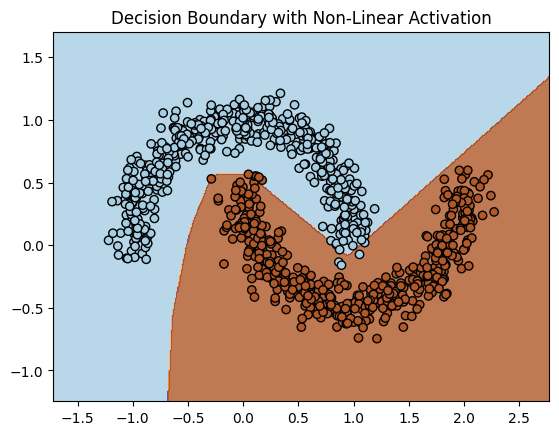

In [ ]:
# Evaluate the non-linear model
y_pred_nonlinear = (model_nonlinear.predict(X_test) > 0.5).astype(int)
accuracy_nonlinear = accuracy_score(y_test, y_pred_nonlinear)
print("Accuracy with Non-Linear Activation:", accuracy_nonlinear)

# Plot decision boundary for non-linear activation model
plot_decision_boundary(model_nonlinear, X, y, "Decision Boundary with Non-Linear Activation")